In [1]:
"""
Train logistic regression model using spatial splits and sklearn pipeline.
Produces:
    - cross-validation metrics
    - out-of-fold predictions
    - final test set evaluation
"""

"""
=================================
==  Primary reporting metrics  ==
=================================
OOF AUCPR — primary ranking metric

OOF Brier score — calibration/probability accuracy
OOF ECE — calibration summary
calibration plot — visual calibration check

OOF log loss — overall probabilistic performance
"""
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime
import json
import os
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

# Use data loading helpers
from src.data.data_loading import load_full_training_pool
from src.data.data_loading import load_test_data
from src.data.data_loading import get_cv_splits

# Use feature handling helpers
from src.data.feature_handling import get_feature_columns



from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from scipy.stats import loguniform

from config.paths import MODEL_RUNS_DIR
from config.paths import RESULTS_DIR
from config.feature_groups import TARGET_COLUMN


RADON_HIGH_CONCENTRATION = 200
INNER_CV_STRATIFY_COLUMN = "provinceterritory"
INNER_CV_GROUP_COLUMN = "spatial_cluster"
OUTER_FOLD_COLUMN = "cv_fold"
TEST_COLUMN = "is_test"

RANDOM_STATE = 42




In [2]:
# ------------------------------------------------------------
# Run identity
# ------------------------------------------------------------
MODEL_NAME = "logreg"   # change to: "random_forest" or "xgboost"

# nickname for run
BATCH_TAG = "overnight_2026_03_20"

SEARCH_SCORING = "neg_log_loss"
N_INNER_SPLITS = 3
N_RANDOM_SEARCH_ITERATIONS = 100


SAFE_SCORING_NAME = str(SEARCH_SCORING).replace("/", "_").replace(" ", "_")
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"{MODEL_NAME}_{BATCH_TAG}_{SAFE_SCORING_NAME}_{RUN_TIMESTAMP}"

RUN_DIR = MODEL_RUNS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_NAME:", MODEL_NAME)
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

MODEL_NAME: logreg
RUN_ID: logreg_overnight_2026_03_20_neg_log_loss_20260320_021633
RUN_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\logreg_overnight_2026_03_20_neg_log_loss_20260320_021633


In [3]:
# Load the data 

# Assume that the split data is already created
# Use helper functions to load the data

train_df = load_full_training_pool().reset_index(drop=True)
# test_df  = load_test_data()

In [4]:
# HELPER FUNCTIONS 

# Build INNER SPLITS
# These inner splits are:
#   - stratified by province
#   - grouped by spatial_cluster
#
# IMPORTANT:
# The returned indices refer to the rows of X_subset passed here.

def make_inner_cv_splits(
    X_subset: pd.DataFrame,
    stratification_column: pd.Series,
    group_column: pd.Series,
    n_splits: int = N_INNER_SPLITS,
    random_state: int = RANDOM_STATE,
):
    inner_splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    inner_splits = list(
        inner_splitter.split(
            X=X_subset,
            y=stratification_column,
            groups=group_column,
        )
    )

    return inner_splits

# Compute calibration metric
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error (ECE) for binary probabilities.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bin_edges[1:-1], right=True)

    ece = 0.0

    for bin_index in range(n_bins):
        in_bin = bin_ids == bin_index
        bin_count = np.sum(in_bin)

        if bin_count > 0:
            bin_accuracy = np.mean(y_true[in_bin])
            bin_confidence = np.mean(y_prob[in_bin])
            ece += (bin_count / len(y_true)) * abs(bin_accuracy - bin_confidence)

    return ece

In [5]:
# ------------------------------------------------------------
# Define Features and Target
# ------------------------------------------------------------

# Build feature list from config file + helper functions
# *** Do this in the pipeline preprocessor !!! ***
feature_columns = get_feature_columns(
    train_df,
    optional_excludes=None,
    extra_drop=None,
    #optional_excludes=["low_impact"],   # standardized optional exclusion set
    #extra_drop=["mean_uranium", "max_uranium"]  # experiment-specific drops
)

# Create target
y_train_full = (train_df[TARGET_COLUMN] > RADON_HIGH_CONCENTRATION).astype(int)


# skip test data for now...
#X_test = test_df[feature_columns]
#y_test = test_df[target_column]

In [6]:
# ------------------------------------------------------------
# Use a helper function to get split data indices that work with sklearn's cross_validate()
cv_split_idx = get_cv_splits(train_df)
# then, cross_validate(pipe, X, y, cv=cv_split_idx)


In [7]:
# ------------------------------------------------------------
# Build Pipeline
# ------------------------------------------------------------
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, feature_columns),
    ],
    remainder="drop",
)


logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                max_iter=5000,
            ),
        ),
    ]
)

In [8]:

# ============================================================
# HYPERPARAMETER SEARCH SPACE
# ============================================================

hyperparam_distributions = [
    {
        "classifier__penalty": ["l1"],
        "classifier__C": loguniform(0.001, 10.0),
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "classifier__penalty": ["l2"],
        "classifier__C": loguniform(0.001, 10.0),
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "classifier__penalty": ["elasticnet"],
        "classifier__C": loguniform(0.001, 10.0),
        "classifier__l1_ratio": [0.3, 0.5, 0.7, 0.9],
        "classifier__class_weight": [None, "balanced"],
    },
]


In [9]:
print("train_df shape:", train_df.shape)
print("TARGET_COLUMN:", TARGET_COLUMN)
print("OUTER_FOLD_COLUMN:", OUTER_FOLD_COLUMN)

print("\nColumns in train_df:")
print(train_df.columns.tolist())

print("\ncv_fold counts:")
print(train_df[OUTER_FOLD_COLUMN].value_counts(dropna=False).sort_index())

outer_folds = sorted(train_df[OUTER_FOLD_COLUMN].dropna().unique())
print("\nouter_folds:", outer_folds)
print("number of outer folds:", len(outer_folds))

train_df shape: (10461, 80)
TARGET_COLUMN: concentration
OUTER_FOLD_COLUMN: cv_fold

Columns in train_df:
['FSA', 'n_days', 'concentration', 'longitude', 'latitude', 'hous_frac_type_single_detached', 'hous_frac_type_highrise', 'hous_frac_type_other_attached', 'hous_frac_type_movable', 'hous_avg_rooms', 'hous_frac_major_repair', 'hous_frac_age_pre_1980', 'hous_frac_age_1981_2000', 'hous_frac_age_post_2001', 'hous_median_value', 'demogr_pop_2016', 'demogr_num_total_dwellings', 'demogr_num_occ_dwellings', 'demogr_median_age', 'demogr_avg_household_size', 'demogr_frac_tenure_owned', 'demogr_frac_tenure_rented', 'demogr_frac_tenure_band', 'socioeco_frac_low_income', 'socioeco_median_income', 'socioeco_frac_high_income', 'socioeco_frac_govt_transfers', 'socioeco_frac_unemployment_rate', 'socioeco_frac_nonlaborer', 'socioeco_frac_bachelor_plus', 'socioeco_frac_overcrowded', 'socioeco_frac_unsuitable_housing', 'socioeco_frac_housing_burden', 'rxtp_intrusive_rocks', 'rxtp_metamorphic_rocks', 'r

In [10]:

# ============================================================
# NESTED CV FOLD
#    Added:
#   - fold-level metrics
#   - OOF probabilities
#   - ROC / PR / calibration artifacts
# ------------------------------------------------------------

CLASSIFICATION_THRESHOLD = 0.1
N_CALIBRATION_BINS = 10

oof_prob = np.full(len(train_df), np.nan)
# best_params_by_outer_fold = {}

outer_fold_results = []
roc_curves = []
pr_curves = []


outer_folds = sorted(train_df[OUTER_FOLD_COLUMN].dropna().unique())

print("About to start nested CV")
print("outer_folds:", outer_folds)
print("number of train rows:", len(train_df))

for outer_fold in outer_folds:

    print("\n" + "=" * 60)
    print(f"OUTER FOLD {outer_fold}")
    print("=" * 60)

    train_mask = train_df[OUTER_FOLD_COLUMN] != outer_fold
    val_mask = train_df[OUTER_FOLD_COLUMN] == outer_fold

    ## Set up outer fold training and validation
    
    # outer train
    # Reset indices for training so inner split indices match row positions 0..N-1
    X_tr = train_df.loc[train_mask, feature_columns].reset_index(drop=True)
    y_tr = y_train_full.loc[train_mask].reset_index(drop=True)
    
    # outer validation
    # Keep original row indices for validation so we can write OOF predictions back
    X_val = train_df.loc[val_mask, feature_columns]
    y_val = y_train_full.loc[val_mask]

    # Set values for inner fold splits
    stratify_tr = train_df.loc[train_mask, INNER_CV_STRATIFY_COLUMN].reset_index(drop=True)
    groups_tr = train_df.loc[train_mask, INNER_CV_GROUP_COLUMN].reset_index(drop=True)

    # -----------------------------
    # Build INNER CV splits from the current outer training fold
    # -----------------------------
    inner_cv_splits = make_inner_cv_splits(
        X_subset=X_tr,
        stratification_column=stratify_tr,
        group_column=groups_tr,
        n_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
    )

    # Optional diagnostics
    print("Outer-train rows:", len(X_tr))
    print("Outer-validation rows:", len(X_val))
    print("Number of inner splits:", len(inner_cv_splits))
    print("Outer-train positive rate:", y_tr.mean())
    print("Outer-validation positive rate:", y_val.mean())

    # -----------------------------
    # Hyperparameter tuning on the current outer-training subset
    # cv=inner_cv_splits uses province-balanced, group-respecting inner folds
    # -----------------------------
    random_search = RandomizedSearchCV(
        estimator=logistic_pipeline,
        param_distributions=hyperparam_distributions,
        n_iter=N_RANDOM_SEARCH_ITERATIONS,
        cv=inner_cv_splits,
        scoring=SEARCH_SCORING,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )

    # IMPORTANT:
    # fit on the REAL target y_tr
    random_search.fit(X_tr, y_tr)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_inner_score = random_search.best_score_

    print("Best params:", best_params)
    print("Best inner mean search score:", best_inner_score)

    # -----------------------------
    # Predict on the held-out OUTER fold
    # -----------------------------
    y_val_prob = best_model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_prob >= CLASSIFICATION_THRESHOLD).astype(int)

    # Store OOF probabilities back into original row positions
    oof_prob[np.where(val_mask)[0]] = y_val_prob

    
    ## Fold metrics
    fold_roc_auc = roc_auc_score(y_val, y_val_prob)
    fold_aucpr = average_precision_score(y_val, y_val_prob)
    fold_logloss = log_loss(y_val, y_val_prob)
    fold_brier = brier_score_loss(y_val, y_val_prob)
    fold_ece = expected_calibration_error(y_val, y_val_prob, n_bins=N_CALIBRATION_BINS)

    fold_accuracy = accuracy_score(y_val, y_val_pred)
    fold_recall = recall_score(y_val, y_val_pred, zero_division=0)
    fold_f1 = f1_score(y_val, y_val_pred, zero_division=0)


    # Curves
    fold_fpr, fold_tpr, _ = roc_curve(y_val, y_val_prob)
    roc_curves.append((fold_fpr, fold_tpr))

    fold_precision, fold_recall_curve, _ = precision_recall_curve(y_val, y_val_prob)
    pr_curves.append((fold_recall_curve, fold_precision))

    
    fold_result = {
        "model_name": MODEL_NAME,
        "run_id": RUN_ID,
        "outer_fold": int(outer_fold),
        "n_train": int(len(X_tr)),
        "n_val": int(len(X_val)),
        "train_positive_rate": float(y_tr.mean()),
        "val_positive_rate": float(y_val.mean()),
        "roc_auc": float(fold_roc_auc),
        "aucpr": float(fold_aucpr),
        "log_loss": float(fold_logloss),
        "brier": float(fold_brier),
        "ece": float(fold_ece),
        "f1": float(fold_f1),
        "recall": float(fold_recall),
        "accuracy": float(fold_accuracy),
        "best_params_json": json.dumps(best_params, sort_keys=True, default=str)
    }

    outer_fold_results.append(fold_result)

    print(
        f"Fold {outer_fold} | "
        f"ROC-AUC: {fold_roc_auc:.4f} | "
        f"AUCPR: {fold_aucpr:.4f} | "
        f"LogLoss: {fold_logloss:.4f} | "
        f"Brier: {fold_brier:.4f} | "
        f"ECE: {fold_ece:.4f} | "
        f"F1: {fold_f1:.4f} | "
        f"Recall: {fold_recall:.4f} | "
        f"Accuracy: {fold_accuracy:.4f}",
        flush=True
    )

    # Convert fold results to dataframe
    outer_fold_results_df = pd.DataFrame(outer_fold_results)
    # save partial progress after every fold
    outer_fold_results_df.to_csv(RUN_DIR / "outer_fold_results.csv", index=False)

print("\n" + "=" * 60)
print("FOLD-LEVEL RESULTS")
print("=" * 60)
display(outer_fold_results_df)


About to start nested CV
outer_folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
number of train rows: 10461

OUTER FOLD 0
Outer-train rows: 8392
Outer-validation rows: 2069
Number of inner splits: 3
Outer-train positive rate: 0.1124880838894185
Outer-validation positive rate: 0.09279845335911067
Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params: {'classifier__C': np.float64(0.0010672476836323724), 'classifier__class_weight': None, 'classifier__penalty': 'l2'}
Best inner mean search score: -0.3421746513632626
Fold 0 | ROC-AUC: 0.5909 | AUCPR: 0.1406 | LogLoss: 0.3074 | Brier: 0.0840 | ECE: 0.0312 | F1: 0.1798 | Recall: 0.5469 | Accuracy: 0.5370



OUTER FOLD 1
Outer-train rows: 8326
Outer-validation rows: 2135
Number of inner splits: 3
Outer-train positive rate: 0.1088157578669229
Outer-validation positive rate: 0.10772833723653395
Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best params: {'classifier__C': np.float64(0.024004075943521632), 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
Best inner mean search score: -0.36336817320428394
Fold 4 | ROC-AUC: 0.6744 | AUCPR: 0.1625 | LogLoss: 0.2713 | Brier: 0.0726 | ECE: 0.0345 | F1: 0.1947 | Recall: 0.7619 | Accuracy: 0.4952



FOLD-LEVEL RESULTS


C:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model_name,run_id,outer_fold,n_train,n_val,train_positive_rate,val_positive_rate,roc_auc,aucpr,log_loss,brier,ece,f1,recall,accuracy,best_params_json
0,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,0,8392,2069,0.112488,0.092798,0.590899,0.140598,0.307367,0.084030,0.031230,0.179795,0.546875,0.536974,"{""classifier__C"": 0.0010672476836323724, ""clas..."
1,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,1,8326,2135,0.108816,0.107728,0.630261,0.174735,0.330943,0.094193,0.005815,0.230931,0.717391,0.485246,"{""classifier__C"": 0.007890004262668575, ""class..."
2,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,2,8345,2116,0.101618,0.136106,0.646364,0.228346,0.389431,0.114711,0.039421,0.307974,0.583333,0.643195,"{""classifier__C"": 0.0036084925884026665, ""clas..."
3,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,3,8418,2043,0.104300,0.126285,0.636188,0.193155,0.369851,0.108343,0.022073,0.258526,0.910853,0.340186,"{""classifier__C"": 0.004809461967501573, ""class..."
4,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,4,8363,2098,0.115748,0.080076,0.674448,0.162463,0.271281,0.072607,0.034476,0.194677,0.761905,0.495234,"{""classifier__C"": 0.024004075943521632, ""class..."


In [11]:
oof_predictions_df = pd.DataFrame({
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "row_index": train_df.index,
    "cv_fold": train_df[OUTER_FOLD_COLUMN].values,
    "y_true": y_train_full.values,
    "oof_prob": oof_prob,
    "oof_pred_01": (oof_prob >= CLASSIFICATION_THRESHOLD).astype(int),
})

# optional useful metadata, if present
for col in ["FSA", "province", TARGET_COLUMN]:
    if col in train_df.columns:
        oof_predictions_df[col] = train_df[col].values

oof_predictions_df.to_csv(RUN_DIR / "oof_predictions.csv", index=False)

In [12]:
print("Max predicted probability in last outer fold:", y_val_prob.max())
print(f"Number >= {CLASSIFICATION_THRESHOLD}:", np.sum(y_val_prob >= CLASSIFICATION_THRESHOLD))
print("Quantiles:", np.quantile(y_val_prob, [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))

Max predicted probability in last outer fold: 0.3042391578199244
Number >= 0.1: 1147
Quantiles: [0.00724426 0.07120856 0.10222528 0.16407572 0.17720732 0.18135635
 0.2510271  0.30423916]


In [13]:
print("Search scoring metric:", random_search.scoring)
print("Classification threshold:", CLASSIFICATION_THRESHOLD)
print("Max predicted probability in last fold:", y_val_prob.max())
print(f"Number >= {CLASSIFICATION_THRESHOLD}:", np.sum(y_val_prob >= CLASSIFICATION_THRESHOLD))
print("Quantiles:", np.quantile(y_val_prob, [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))

Search scoring metric: neg_log_loss
Classification threshold: 0.1
Max predicted probability in last fold: 0.3042391578199244
Number >= 0.1: 1147
Quantiles: [0.00724426 0.07120856 0.10222528 0.16407572 0.17720732 0.18135635
 0.2510271  0.30423916]


In [14]:
# ------------------------------------------------------------
# Overall OOF metrics
# ------------------------------------------------------------

if np.any(np.isnan(oof_prob)):
    raise ValueError("Some OOF probabilities are still NaN.")

train_df = train_df.copy()
train_df["oof_prob"] = oof_prob
train_df["oof_pred_0p1"] = (train_df["oof_prob"] >= CLASSIFICATION_THRESHOLD).astype(int)

oof_roc_auc = roc_auc_score(y_train_full, train_df["oof_prob"])
oof_aucpr = average_precision_score(y_train_full, train_df["oof_prob"])
oof_logloss = log_loss(y_train_full, train_df["oof_prob"])
oof_brier = brier_score_loss(y_train_full, train_df["oof_prob"])
oof_ece = expected_calibration_error(y_train_full, train_df["oof_prob"], n_bins=N_CALIBRATION_BINS)

oof_accuracy = accuracy_score(y_train_full, train_df["oof_pred_0p1"])
oof_recall = recall_score(y_train_full, train_df["oof_pred_0p1"], zero_division=0)
oof_f1 = f1_score(y_train_full, train_df["oof_pred_0p1"], zero_division=0)

print("\n" + "=" * 60)
print("OVERALL OOF METRICS")
print("=" * 60)
print("Positive prevalence:", y_train_full.mean())
print("OOF ROC-AUC:", oof_roc_auc)
print("OOF AUCPR:", oof_aucpr)
print("OOF LogLoss:", oof_logloss)
print("OOF Brier:", oof_brier)
print("OOF ECE:", oof_ece)
print("OOF Accuracy:", oof_accuracy)
print("OOF Recall:", oof_recall)
print("OOF F1:", oof_f1)


OVERALL OOF METRICS
Positive prevalence: 0.10859382468215276
OOF ROC-AUC: 0.628664095835064
OOF AUCPR: 0.17110791288787475
OOF LogLoss: 0.333743797168881
OOF Brier: 0.09476740943794444
OOF ECE: 0.0054689802214567314
OOF Accuracy: 0.5010993212885957
OOF Recall: 0.7051056338028169
OOF F1: 0.23486292332502565


In [15]:
summary_results = {
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "batch_tag": BATCH_TAG,
    "search_scoring": SEARCH_SCORING,
    "n_rows": int(len(train_df)),
    "positive_rate": float(y_train_full.mean()),
    "n_outer_folds": int(train_df[OUTER_FOLD_COLUMN].nunique()),

    "oof_roc_auc": float(oof_roc_auc),
    "oof_aucpr": float(oof_aucpr),
    "oof_log_loss": float(oof_logloss),
    "oof_brier": float(oof_brier),
    "oof_ece": float(oof_ece),
    "oof_f1": float(oof_f1),
    "oof_recall": float(oof_recall),

    "mean_fold_roc_auc": float(pd.DataFrame(outer_fold_results)["roc_auc"].mean()),
    "mean_fold_aucpr": float(pd.DataFrame(outer_fold_results)["aucpr"].mean()),
    "mean_fold_log_loss": float(pd.DataFrame(outer_fold_results)["log_loss"].mean()),
    "mean_fold_brier": float(pd.DataFrame(outer_fold_results)["brier"].mean()),
    "mean_fold_ece": float(pd.DataFrame(outer_fold_results)["ece"].mean()),
}

with open(RUN_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary_results, f, indent=2)

pd.DataFrame([summary_results]).to_csv(RUN_DIR / "summary_metrics.csv", index=False)

In [16]:
thresholds_to_check = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

for threshold in thresholds_to_check:
    oof_pred = (train_df["oof_prob"] >= threshold).astype(int)

    threshold_accuracy = accuracy_score(y_train_full, oof_pred)
    threshold_recall = recall_score(y_train_full, oof_pred, zero_division=0)
    threshold_f1 = f1_score(y_train_full, oof_pred, zero_division=0)

    print(
        f"Threshold {threshold:.2f} | "
        f"Accuracy: {threshold_accuracy:.4f} | "
        f"Recall: {threshold_recall:.4f} | "
        f"F1: {threshold_f1:.4f} | "
        f"Predicted positives: {oof_pred.sum()}"
    )

Threshold 0.05 | Accuracy: 0.2094 | Recall: 0.9525 | F1: 0.2074 | Predicted positives: 9298
Threshold 0.10 | Accuracy: 0.5011 | Recall: 0.7051 | F1: 0.2349 | Predicted positives: 5685
Threshold 0.15 | Accuracy: 0.7742 | Recall: 0.3231 | F1: 0.2371 | Predicted positives: 1960
Threshold 0.20 | Accuracy: 0.8702 | Recall: 0.0960 | F1: 0.1383 | Predicted positives: 440


Threshold 0.25 | Accuracy: 0.8905 | Recall: 0.0106 | F1: 0.0205 | Predicted positives: 33
Threshold 0.30 | Accuracy: 0.8912 | Recall: 0.0000 | F1: 0.0000 | Predicted positives: 2


In [17]:
# ------------------------------------------------------------
# Mean ± std across outer folds
# ------------------------------------------------------------

metric_columns = [
    "roc_auc",
    "aucpr",
    "log_loss",
    "brier",
    "ece",
    "accuracy",
    "recall",
    "f1",
]

print("\n" + "=" * 60)
print("MEAN PERFORMANCE ACROSS OUTER FOLDS")
print("=" * 60)

for metric_name in metric_columns:
    metric_mean = outer_fold_results_df[metric_name].mean()
    metric_std = outer_fold_results_df[metric_name].std()
    print(f"{metric_name}: {metric_mean:.4f} ± {metric_std:.4f}")


MEAN PERFORMANCE ACROSS OUTER FOLDS
roc_auc: 0.6356 ± 0.0302
aucpr: 0.1799 ± 0.0332
log_loss: 0.3338 ± 0.0475
brier: 0.0948 ± 0.0172
ece: 0.0266 ± 0.0132
accuracy: 0.5002 ± 0.1091
recall: 0.7041 ± 0.1463
f1: 0.2344 ± 0.0514


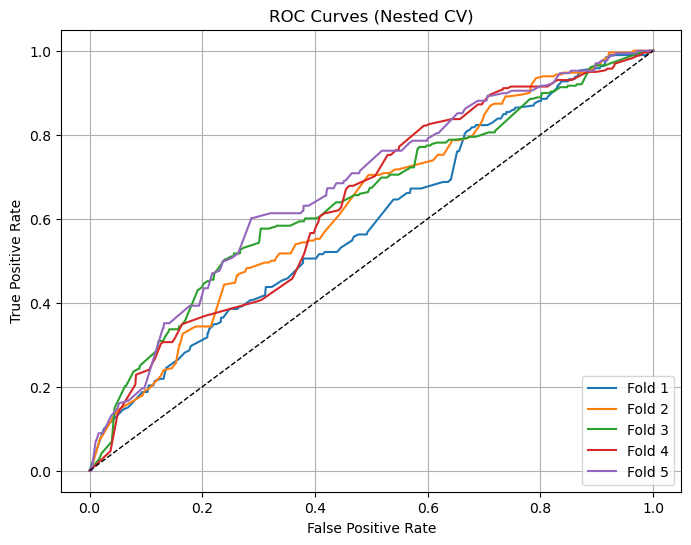

In [18]:
# ------------------------------------------------------------
# ROC curves for all outer folds
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for i, (fpr, tpr) in enumerate(roc_curves, start=1):
    plt.plot(fpr, tpr, label=f"Fold {i}")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Nested CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

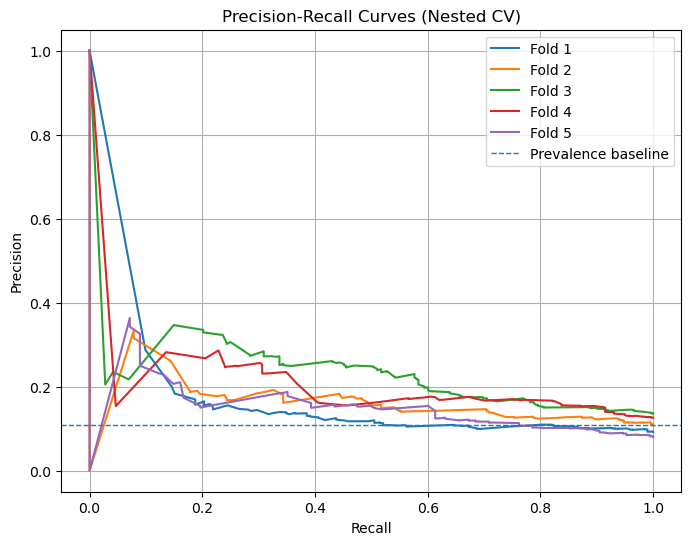

In [19]:
# ------------------------------------------------------------
# Precision-Recall curves for all outer folds
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for i, (recall_curve_values, precision_values) in enumerate(pr_curves, start=1):
    plt.plot(recall_curve_values, precision_values, label=f"Fold {i}")

baseline_prevalence = y_train_full.mean()
plt.axhline(y=baseline_prevalence, linestyle="--", linewidth=1, label="Prevalence baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Nested CV)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

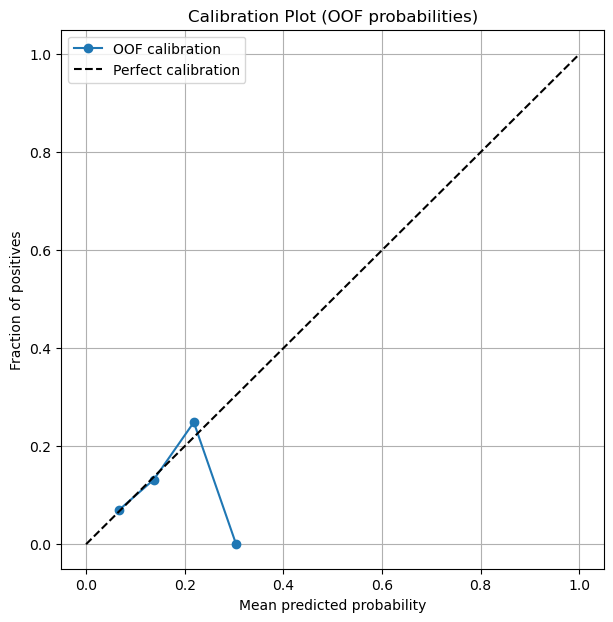

In [20]:
# ------------------------------------------------------------
# Calibration plot from OOF probabilities
# ------------------------------------------------------------

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_train_full,
    train_df["oof_prob"],
    n_bins=N_CALIBRATION_BINS,
    strategy="uniform",
)

plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="OOF calibration")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (OOF probabilities)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

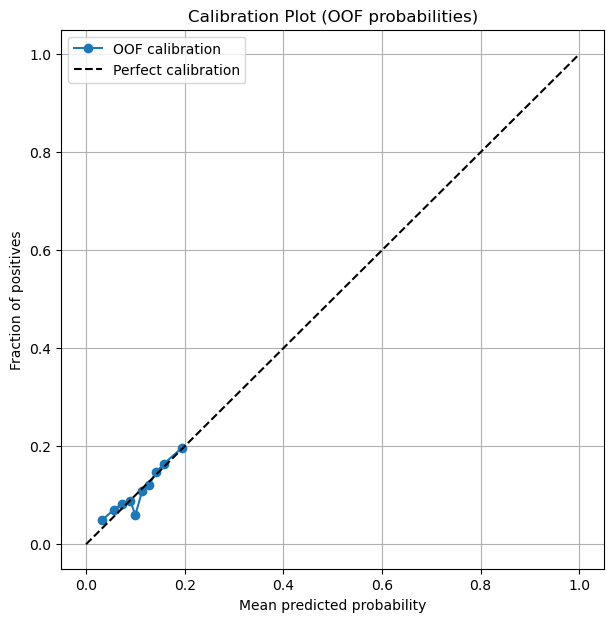

In [21]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_train_full,
    train_df["oof_prob"],
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="OOF calibration")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (OOF probabilities)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [22]:
# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

train_df.to_csv(RUN_DIR / "logreg_oof_predictions_with_metadata.csv", index=False)
outer_fold_results_df.to_csv(RUN_DIR / "logreg_outer_fold_results.csv", index=False)
summary_results_logreg = {
    "run_id": RUN_ID,
    "run_timestamp": RUN_TIMESTAMP,
    "search_scoring": SEARCH_SCORING,
    "n_random_search_iterations": N_RANDOM_SEARCH_ITERATIONS,
    "n_inner_splits": N_INNER_SPLITS,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "n_calibration_bins": N_CALIBRATION_BINS,
    "oof_roc_auc": oof_roc_auc,
    "oof_aucpr": oof_aucpr,
    "oof_logloss": oof_logloss,
    "oof_brier": oof_brier,
    "oof_ece": oof_ece,
    "oof_accuracy": oof_accuracy,
    "oof_recall": oof_recall,
    "oof_f1": oof_f1,
    "prevalence": y_train_full.mean(),
    "n_train_rows": len(train_df),
}

summary_results_logreg_df = pd.DataFrame([summary_results_logreg])

summary_results_logreg_df.to_csv(
    RUN_DIR / "logreg_summary_results.csv",
    index=False
)

display(summary_results_logreg_df)

,run_id,run_timestamp,search_scoring,n_random_search_iterations,n_inner_splits,classification_threshold,n_calibration_bins,oof_roc_auc,oof_aucpr,oof_logloss,oof_brier,oof_ece,oof_accuracy,oof_recall,oof_f1,prevalence,n_train_rows
0,logreg_overnight_2026_03_20_neg_log_loss_20260...,20260320_021633,neg_log_loss,100,3,0.1,10,0.628664,0.171108,0.333744,0.094767,0.005469,0.501099,0.705106,0.234863,0.108594,10461
